## Building MicroGrad from Scratch

In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def f(x):
    return 3*x**2 - 4*x + 5

In [8]:
f(3.0)

20.0

[-5.   -4.75 -4.5  -4.25 -4.   -3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25
 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75
  4.    4.25  4.5   4.75]
[100.      91.6875  83.75    76.1875  69.      62.1875  55.75    49.6875
  44.      38.6875  33.75    29.1875  25.      21.1875  17.75    14.6875
  12.       9.6875   7.75     6.1875   5.       4.1875   3.75     3.6875
   4.       4.6875   5.75     7.1875   9.      11.1875  13.75    16.6875
  20.      23.6875  27.75    32.1875  37.      42.1875  47.75    53.6875]


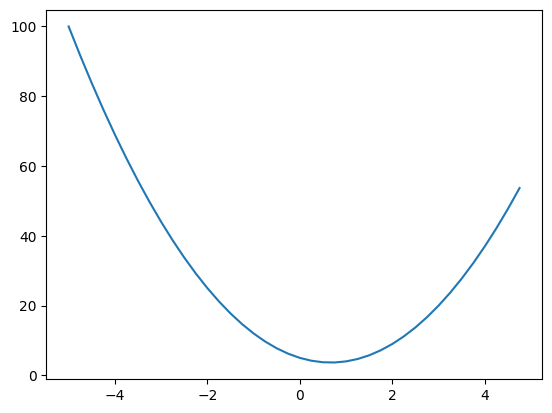

In [15]:
xs = np.arange(-5, 5, 0.25)
print(xs)
ys = f(xs)
print(ys)

plt.plot(xs,ys)




In [30]:
a = 2
b = -3
c = 10

d = a*b + c
print(d) #4

h = 0.0001
b+=h
d2 = a*b + c
print(d2) #3.997
#the value is decresing because of negative value of b
#that means the sign of the value will be negative

print("slope", (d2-d)/h) #derivata partiala in raport cu a; 
#(dc a? doar pe a l am modificat putin)

4
4.0002
slope 2.0000000000042206


#### NN are pretty massive mathematical expressions, so we need some Data Structure that maintain this expression.

In [587]:
class Value:
    def __init__(self,data, _children=(), _op='', label=''): #_children is a tuple
        self.data = data
        self.prev = set(_children)
        self.op = _op
        self.grad = 0.0
        self._backward = lambda: None
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    
    def __add__(self,other):  #python will internally call this function when we use the '+' operator
        other = other if isinstance(other, Value) else Value(other) #for case like 'a+3' where 3 is not a Value object -> Error; so we convert 3 to a Value object
        out = Value(self.data + other.data, (self,other), '+')
    #the new Value object has as childrens the two object that are added
    #                          ________
    #                         |        |
    #                         |  out   |     <--- Value object
    #                         |________|
    #                         /        \
    #                        /          \
    #                       /            \
    #         _______________          _____________ 
    #        |   childrem    |        |   children  |
    #        |    (self)     |   |+|  |    (other)  |    <--- Value objects
    #        |_______________|        |_____________|

        def _backward():
            #the local derivative of the '+' operation is 1
            # the '+' is distribuitor of gradient(more exactly the gradient of the out value is copied to the children)
            #according to the chain rule, while backpropagating the gradient of the childrens is: '1 * out.grad'(gradient of the output value, or the parent)
            self.grad += 1.0 * out.grad   #chain rule
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):  #other + self
        return self + other

    def __mul__(self,other):
        other = other if isinstance(other, Value) else Value(other) #for case like 'a*3' where 3 is not a Value object -> Error; so we convert 3 to a Value object
        out = Value(self.data * other.data, (self,other), '*')

        def _backward():
            #the local derivative of the '*' operation is the other value
            self.grad += other.data * out.grad   #chain rule
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self,other):  #other * self
        #in case of other * self, we swap the self and other
        return self * other


    def tanh(self):     #activation function
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad = (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1

    def __sub__(self, other):  #self - other
        return self + (-other)
    
    def __rsub__(self, other):  #other - self
        return other + (-self)

    def exp(self):   
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():   #derivative of e^x is e^x
            #out.grad(e^x) * out.grad(chain rule)
            self.grad += out.grad * out.data 
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data**(other-1)) * out.grad
        out._backward = _backward
        return out
        
        
    def __truediv__(self,other):  #self / other
        return self * other**-1 #will call the __pow__ function

    def __rtruediv__(self,other):  #other / self
        return other * self**-1 #will call the __pow__ function


    def backward(self):

        topo = []  #will store the node in their order (from left to right)
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v.prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [173]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # Creează nodul 'record' pentru valoare, afișând și data și gradientul
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n.op:
            # Creează nodul pentru operație
            dot.node(name=uid + n.op, label=n.op)
            # Conectează nodul operației la nodul valorii
            dot.edge(uid + n.op, uid)
        
    for n1, n2 in edges:
            #connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2.op)
            
    return dot
    

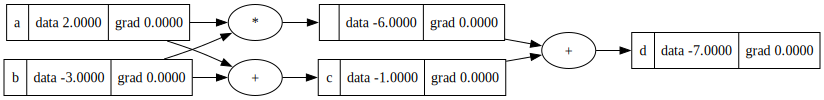

In [115]:
draw_dot(d)

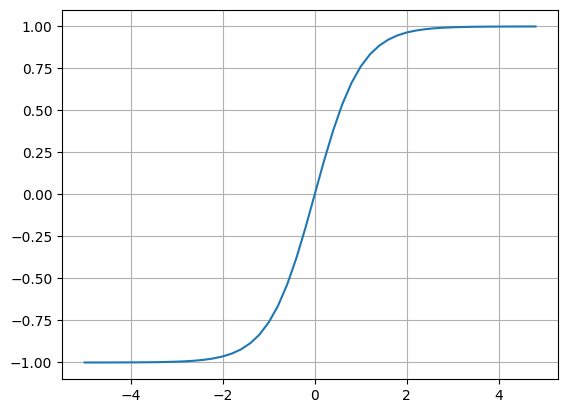

In [99]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2)));
plt.grid();

In [120]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias of the neuron
b = Value(6.8813735870195432, label='b')

#x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'


In [122]:
o.grad = 1.0

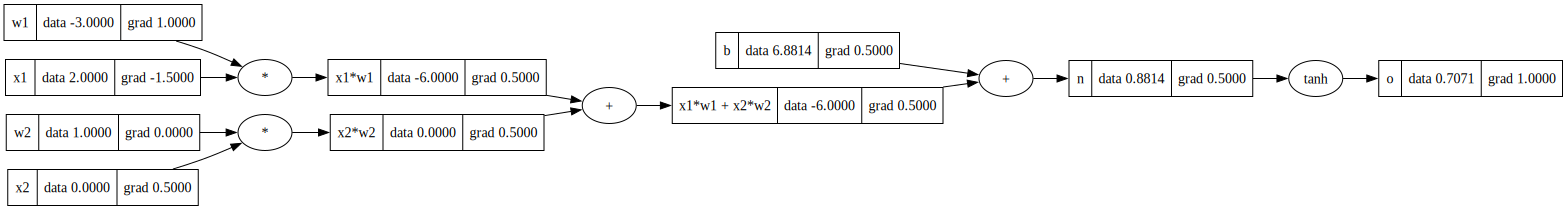

In [142]:
draw_dot(o)

In [129]:
# o = tanh(n)
# do/dn = 1 -o**2 - derviata locala a functiei tanh in raport cu n

1- o.data**2

0.4999999999999999

In [135]:
n.grad = 0.5
b.grad = 0.5
x1w1x2w2.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5

In [141]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad
x1.grad = w1.data  * x1w1.grad
w1.grad = x1.data * x1w1.grad

## After implementing the _backward() function

In [174]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias of the neuron
b = Value(6.8813735870195432, label='b')

#x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

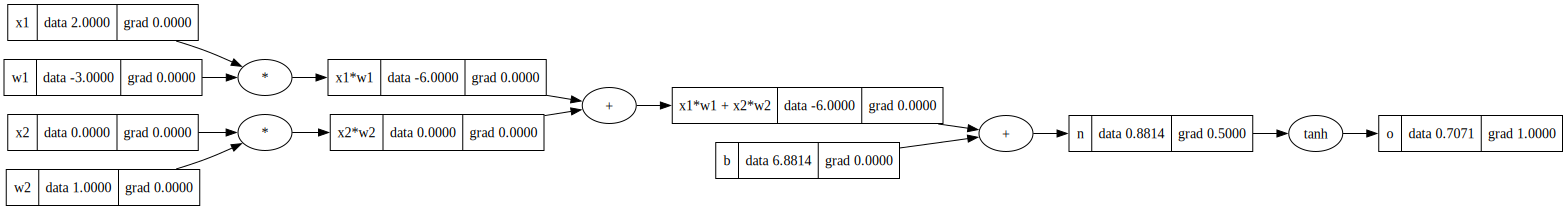

In [153]:
draw_dot(o)

#### Call _backward() in the right order

In [ ]:

# o is the output of the tanh function.
# according to the tanh function: 'self.grad = (1 - t**2) * out.grad'; but the out.grad is 0 (initialized with 0 in the Value class, since this is the first _backward call)
#so we set the o.grad = 1.0
o.grad = 1.0 
o._backward()

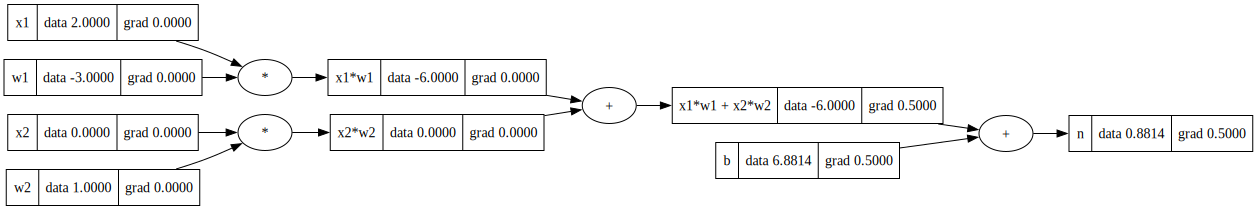

In [155]:
n._backward()
draw_dot(n)

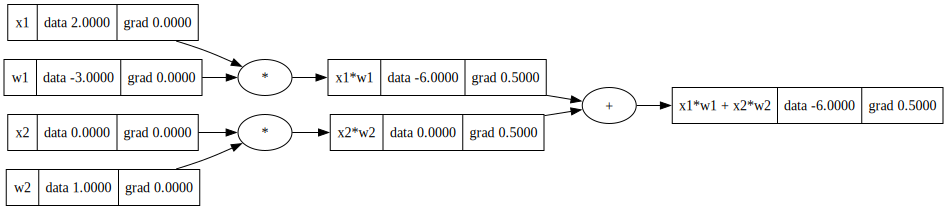

In [157]:
x1w1x2w2._backward()
draw_dot(x1w1x2w2)

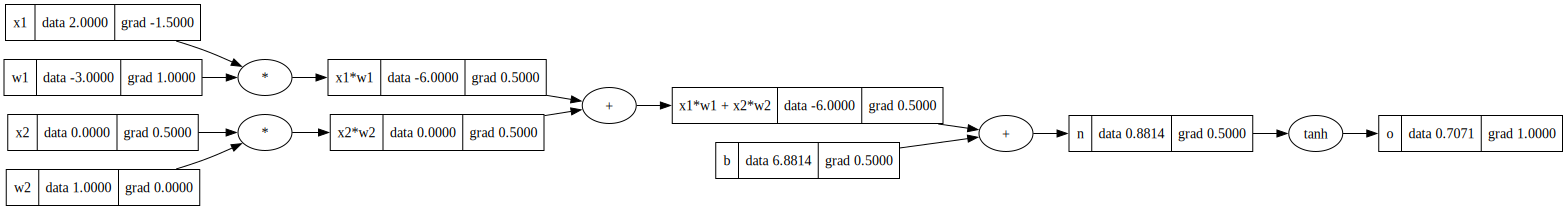

In [161]:
x1w1._backward()
x2w2._backward()
draw_dot(o)

In [ ]:
o.backward()

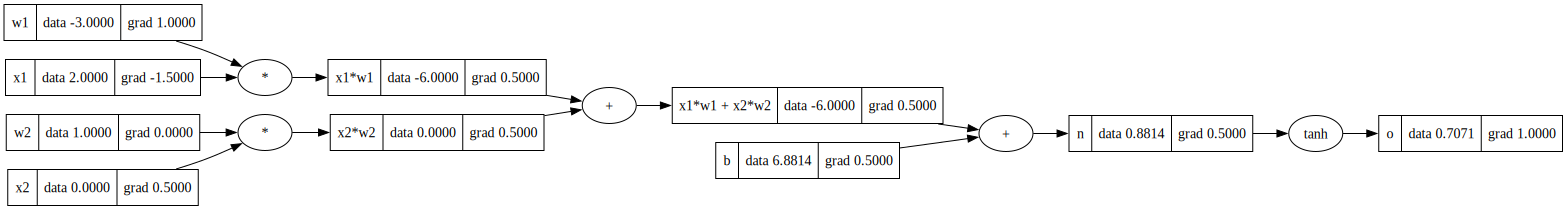

In [176]:
draw_dot(o)

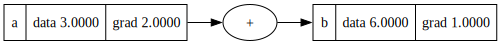

In [179]:
a = Value(3.0, label='a')
b = a + a; b.label = 'b'

b.backward()
draw_dot(b)

In [192]:
a = Value(3.0, label='a')
a.exp()

Value(data=20.085536923187668)

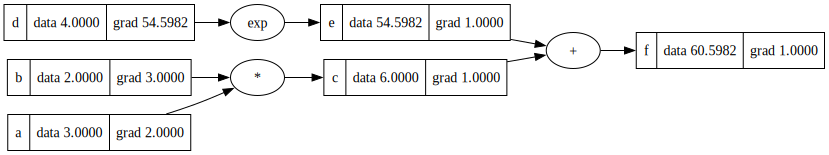

In [193]:
a = Value(3.0, label='a')
b = Value(2.0, label='b')
c = a*b; c.label = 'c'
d = Value(4.0, label='d')
e = d.exp(); e.label = 'e'
f = c+e; f.label = 'f'
f.backward()
draw_dot(f)


In [251]:
a = Value(1.0, label='a')
b = Value(2.0, label='b')

#FLOW -> a - b = a + (-b)
#See '-b' -> __neg__ function: b * -1
#See '*' -> __mul__ function: transform the '-1' into a Value object; otherwise Type error
#   --> '-b' is a Value object with the data of -b
#   --> a + (-b) will call the __add__ function; both 'a' and '-b' are Value objects --> DONE


### Redifining the Tanh function iteratively

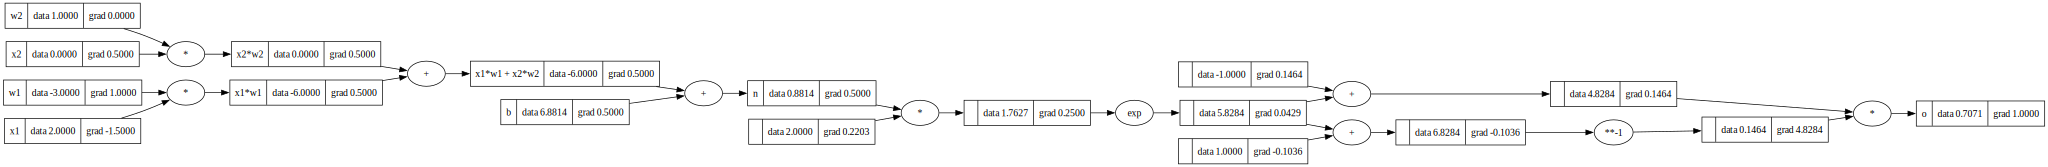

In [254]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias of the neuron
b = Value(6.8813735870195432, label='b')

#x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
#--------------------------------
e = (2*n).exp()
o = (e - 1) / (e + 1)
o.label = 'o'
o.backward()
draw_dot(o)

## Above - the flow of ONE Neuron

## Building Micrograd - PyTorch

In [255]:
import torch

In [536]:
x1 = torch.Tensor([2.0]).double() #double for .float64 instead of .float32
x2 = torch.Tensor([0.0]).double()
w1 = torch.Tensor([-3.0]).double()
w2 = torch.Tensor([1.0]).double()
b = torch.Tensor([6.8813735870195432]).double()
x1.requires_grad = True
x2.requires_grad = True
w1.requires_grad = True
w2.requires_grad = True
b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print("----")
print('x1.grad', x1.grad.item())
print('x2.grad', x2.grad.item())
print('w1.grad', w1.grad.item())
print('w2.grad', w2.grad.item())


0.7071066904050358
----
x1.grad -1.5000003851533106
x2.grad 0.5000001283844369
w1.grad 1.0000002567688737
w2.grad 0.0


## Build Neuro Nets

In [559]:
import random

class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)] #list of weights
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):  #function called when the object is called; eg. n(x) - n=object, x=input
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh() #activation function
        return out

    def parameters(self):
        return self.w + [self.b] #weights = number of inputs in the neuron 
        

class Layer:

    def __init__(self,nin,nout):
        #nin = number of inputs of the neuron
        #nout = number of neurons in the layer
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        # return [p for n in self.neurons for p in n.parameters()]
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()     #list with params of the neuron
            params.extend(ps)            #list with all params of the layer(for each neuron)
        return params


class MLP:

    def __init__(self, nin, nouts):
        #nin = number of inputs of the neuron
        #nouts = list of number of neurons in each layer
        sz = [nin] + nouts  #[2](number neur inputs) + [3,4,5](number of neurons in each layer) -> [2,3,4,5]
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
        #eg. Layer(2,3) -> 3 neurons with 2 inputs each
        #eg. Layer(3,4) -> 4 neurons with 3 inputs each

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        # return [p for layer in self.layers for p in layer.parameters()]
        params = []
        for layer in self.layers:
            for neuron in layer.neurons:
                ps = neuron.parameters() 
                params.extend(ps)
        return params

x = [2.0, 3.0, -4.0]
n = Neuron(3)
print(f"n.w: {n.w}")
print(f"n.b: {n.b}")
print(n)
n(x)
draw_dot(n(x))
print(n(x))



# x = [2.0, 3.0]
# n = Layer(2,3) #3 neuron with 2 inputs each in the layer
# n(x)

x = [2.0, 3.0, -3.0]
n = MLP(3,[4,4,1])
n(x)

print(f"Parameters of the MLP: {n.parameters()}")

n.w: [Value(data=0.512374025343334), Value(data=-0.18425953268413897), Value(data=-0.775464902413499)]
n.b: Value(data=-0.0075744539999564875)
Value(data=0.9984038494102778)
Parameters of the MLP: [Value(data=0.3263695633146797), Value(data=-0.5176029723882127), Value(data=0.48388634831411825), Value(data=-0.8762894945948196), Value(data=-0.20714526265925493), Value(data=0.40466928294627613), Value(data=-0.9377629013507098), Value(data=-0.8913249941579835), Value(data=-0.7330608833779364), Value(data=0.4831709063956773), Value(data=0.3740841431378552), Value(data=0.9107470257595203), Value(data=-0.3300080583413547), Value(data=-0.5618041322553484), Value(data=-0.451542556963509), Value(data=0.5381489000957886), Value(data=0.633243491273247), Value(data=-0.6132988714805288), Value(data=0.9831778933432704), Value(data=-0.11130270471794868), Value(data=0.010754612264292529), Value(data=0.5033750285388121), Value(data=0.4573905979478434), Value(data=-0.5935012325275308), Value(data=-0.5698

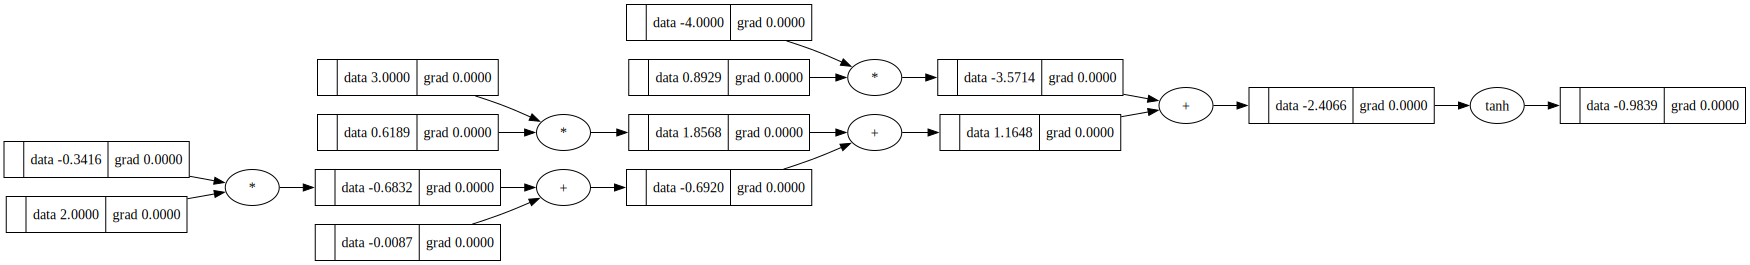

In [548]:
draw_dot(n(x))

## ---------FLOW of the DIAGRAM---------  (for 1 NEURON)
#### There is little mistake: 
#####   - after each '*' between the actual weight and its correspondent data(wi * xi) the bias is added to the output,
#####   - the bias should be added after all the weights are multiplied to their correspondent data -> [(wi * xi) + b]
## ------------------------------------------------------------
### WEIGHTS: [-0.3416,   0.6189,   0.8929]; BIAS: [-0.0087] - Value Objects
### INPUT DATA: [2.0, 3.0, -4.0]
## ------------------------------------------------------------
### --> first x(x[0]) is '*' with first random weight(weights[0]) ==> 2.0 * -0.3416 = -0.6832
### --> the second data x(x[1]) is '*' with the second random generated weight ==> 3.0 * 0.6189 = 1.8568
### --> the third data x(x[2]) is '*' with the third random generated weight ==> -4.0 * 0.8929 = -3.5714
### --> all the 3 outputs are summed together  ==>  -0.6832 + 1.8568 + (-3.5714) = -2.3978
### --> the bias is added to this final sum ==> -2.3978 + (-0.0087) = -2.4065
### --> the output is activated with tanh function ==> -0.9838840119725816
## ------> FINAL OUTPUT OF THE NEURON = -0.9838840119725816 <-------

In [558]:
def tanh(x):
    return (math.exp(2*x)-1)/(math.exp(2*x)+1)
val = tanh(-2.4065)
val

-0.9838840119725816

In [383]:
n.parameters()

[Value(data=-0.265974063096877),
 Value(data=-0.18335935107368928),
 Value(data=0.692149105152557),
 Value(data=-0.5308179020379646),
 Value(data=-0.2458629458905328),
 Value(data=-0.08043566816291836),
 Value(data=-0.06220631438902502),
 Value(data=-0.700417297542234),
 Value(data=0.4346150402131137),
 Value(data=0.7335961007616274),
 Value(data=0.6093404224887939),
 Value(data=0.157965547985218),
 Value(data=0.1654149082397698),
 Value(data=0.5472439783739933),
 Value(data=-0.09750896318048219),
 Value(data=-0.3557286323796458),
 Value(data=0.7300519392914155),
 Value(data=-0.302616566590858),
 Value(data=-0.6522686142022809),
 Value(data=-0.15541246707864942),
 Value(data=0.1245487051345513),
 Value(data=0.30636354567181723),
 Value(data=0.057632670800796815),
 Value(data=-0.834905060338323),
 Value(data=-0.7070994856943176),
 Value(data=0.7841065919839421),
 Value(data=-0.3308329837631441),
 Value(data=-0.3726502604205886),
 Value(data=0.7202380041080148),
 Value(data=0.09813639091

In [567]:
def visualize_mlp_text(mlp):
    """Printează o reprezentare textuală structurată a parametrilor unui MLP."""
    print("--- Arhitectura MLP ---")
    print("Input data: ", x)
    
    # Parcurgem fiecare strat cu indexul său
    for i, layer in enumerate(mlp.layers):
        print(f"\n[ Layer {i} ] - ({len(layer.neurons[0].w)} intrări, {len(layer.neurons)} neuroni)")
        
        # Parcurgem fiecare neuron din strat cu indexul său
        for j, neuron in enumerate(layer.neurons):
            print(f"   Neuron {j}:")
            # Afișăm bias-ul formatat
            print(f"    Bias: Value(data={neuron.b.data:.4f})")
            
            # Afișăm fiecare pondere (weight) formatată
            print(f"    Weights:")
            for k, weight in enumerate(neuron.w):
                print(f"      w[{k}]: Value(data={weight.data:.4f})")
                
    print("\n-----------------------")

# Cum se folosește:
# Presupunând că ai un MLP numit 'n'
visualize_mlp_text(n)


--- Arhitectura MLP ---
Input data:  [2.0, 3.0, -3.0]

[ Layer 0 ] - (3 intrări, 4 neuroni)
   Neuron 0:
    Bias: Value(data=-0.8763)
    Weights:
      w[0]: Value(data=0.3264)
      w[1]: Value(data=-0.5176)
      w[2]: Value(data=0.4839)
   Neuron 1:
    Bias: Value(data=-0.8913)
    Weights:
      w[0]: Value(data=-0.2071)
      w[1]: Value(data=0.4047)
      w[2]: Value(data=-0.9378)
   Neuron 2:
    Bias: Value(data=0.9107)
    Weights:
      w[0]: Value(data=-0.7331)
      w[1]: Value(data=0.4832)
      w[2]: Value(data=0.3741)
   Neuron 3:
    Bias: Value(data=0.5381)
    Weights:
      w[0]: Value(data=-0.3300)
      w[1]: Value(data=-0.5618)
      w[2]: Value(data=-0.4515)

[ Layer 1 ] - (4 intrări, 4 neuroni)
   Neuron 0:
    Bias: Value(data=0.0108)
    Weights:
      w[0]: Value(data=0.6332)
      w[1]: Value(data=-0.6133)
      w[2]: Value(data=0.9832)
      w[3]: Value(data=-0.1113)
   Neuron 1:
    Bias: Value(data=-0.4438)
    Weights:
      w[0]: Value(data=0.5034)
 

Value(data=-0.05735816393399366)


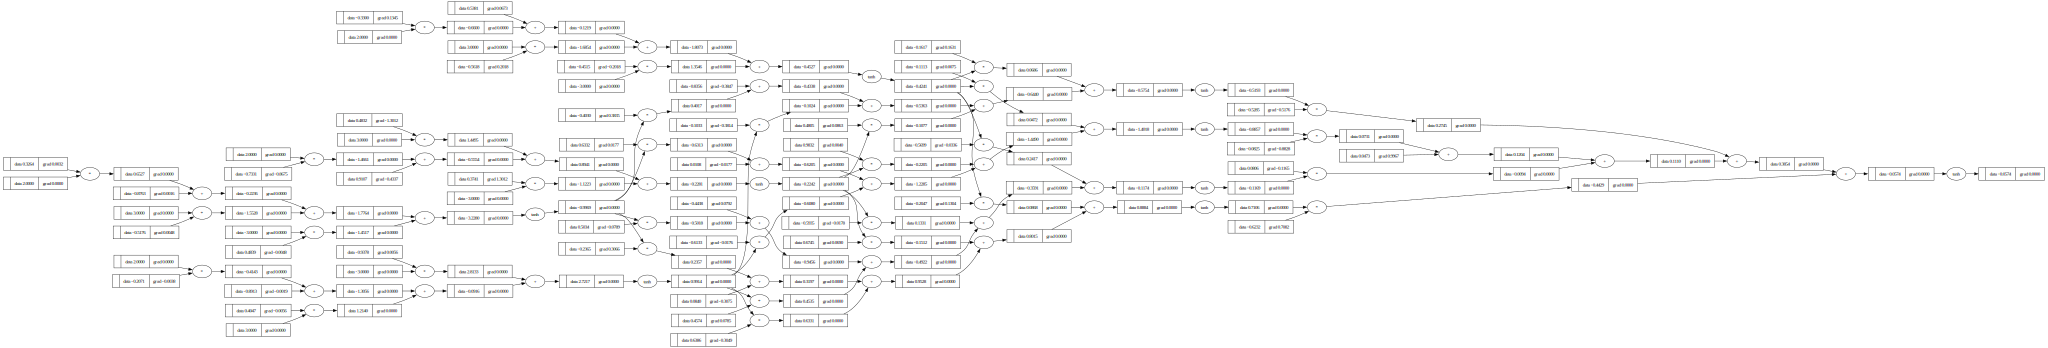

In [568]:
n(x).backward()
print(n(x))
draw_dot(n(x))

In [575]:

xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] #desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=-0.38301720032085657),
 Value(data=0.7815869074905105),
 Value(data=-0.3132585055995482),
 Value(data=-0.13413182621508515)]

In [576]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=6.8446573646902715)

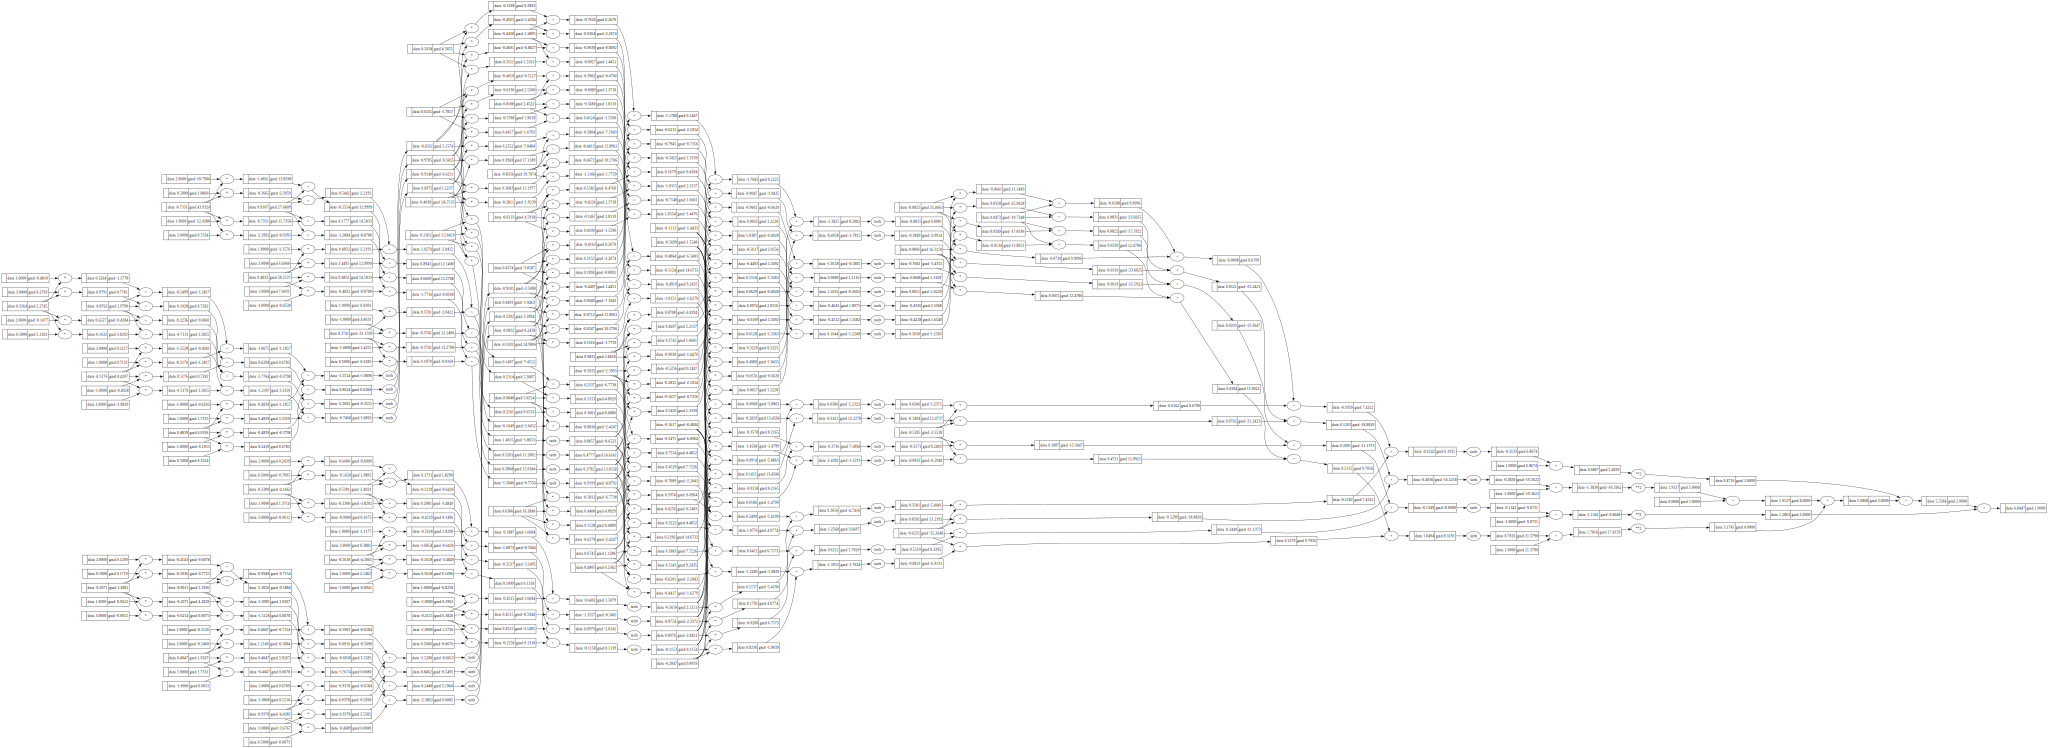

In [579]:
loss.backward()

draw_dot(loss)

In [389]:
print(f"Current value of the gradient of the first neuron {n.layers[0].neurons[0].w[0].grad}")
#since is a negative value(sign of gradient is negative), the function is decreasing
#the definition of derivative says that adding a little h=0.0001 to a parameter that will
#decrease the final output of the function(compared to the initial output) => that means the derivative is negative
# --> increasing the weights will automatically decrease the loss function

print(f"Current value of weights of the first neuron {n.layers[0].neurons[0].w[0].data}")

Current value of the gradient of the first neuron 4.204124316276871
Current value of weights of the first neuron -0.265974063096877


In [580]:
for p in n.parameters():
    p.data += -0.01 * p.grad

## WHY '-0.001' * p.grad??
##### Eu vrea ca functia mea sa scada(f = Loss)
### CAZ 1). Derivata Pozitiva:
##### ---> Daca cresc parametru cu 0.01 atunci Loss ul creste! NU Vreau asta!
##### ---> Solutia: -0.01 * p.grad ==> valoare negativa
##### ---> adun o valoarea negativa la parametru, deci parametru scade, automat Loss-ul scade pentru ca derivata e pozitiva!

### CAZ 2). Derivata Negativa:
##### ---> Daca cresc parametru cu 0.01 atunci Loss ul scade! Perfect!
##### ---> Solutia: -0.01 * p.grad ==> valoare pozitiva
##### ---> adun o valoarea pozitiva la parametru, automat Loss-ul scade pentru derivata e negativa!

In [396]:
print(f"value of weights of the first neuron {n.layers[0].neurons[0].w[0].data}")

value of weights of the first neuron -0.3500565494224144


In [530]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=7.309529028083002e-05)

In [531]:
loss.backward()

In [533]:
ypred

[Value(data=0.9926685489814174),
 Value(data=-0.999994123778354),
 Value(data=-0.9997055740912838),
 Value(data=0.9956115612004666)]

In [585]:
for k in range(10):
    # forward pass 
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))
    
    #backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    #update
    for p in n.parameters():
        p.data -= 0.05 * p.grad

    print(f"Epoch {k}, Loss: {loss.data}")

Epoch 0, Loss: 1.0058001475857737e-05
Epoch 1, Loss: 1.0057597871222713e-05
Epoch 2, Loss: 1.0057194298968288e-05
Epoch 3, Loss: 1.00567907590925e-05
Epoch 4, Loss: 1.0056387251589919e-05
Epoch 5, Loss: 1.0055983776458077e-05
Epoch 6, Loss: 1.0055580333692022e-05
Epoch 7, Loss: 1.0055176923288812e-05
Epoch 8, Loss: 1.0054773545243999e-05
Epoch 9, Loss: 1.0054370199553135e-05


In [586]:
ypred

[Value(data=0.9977579598313985),
 Value(data=-1.0),
 Value(data=-0.9999703021169464),
 Value(data=0.9977579598313874)]